<a href="https://colab.research.google.com/github/GBharathG/Hotel-Booking-EDA/blob/main/Elite_Hotels_Hotel_Booking_EDA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Elite Hotels International — Hotel Booking Demand EDA





## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## 2. Upload the Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
print("Uploaded file:", file_name)


Saving hotel_bookings.csv to hotel_bookings.csv
Uploaded file: hotel_bookings.csv


## 3. Load the Dataset

In [ ]:
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully.
Rows: 119390
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


## 4. Initial Inspection

In [ ]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nBasic statistics:")
display(df.describe(include="all").T)


Shape: (119390, 32)

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:


,Data Type
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## 5. Missing Values — Before Cleaning

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing[missing["Missing Values"] > 0])


,Missing Values,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


## 6. Duplicate Check

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 31994


## 7. Data Cleaning

In [ ]:
# Work on a copy
cleaned_df = df.copy()

# Convert children to numeric where necessary
cleaned_df["children"] = pd.to_numeric(cleaned_df["children"], errors="coerce")

# Fill missing children with 0 (no children recorded)
cleaned_df["children"] = cleaned_df["children"].fillna(0)

# Agent and company are identifiers; retain missing values as "Unknown"
cleaned_df["agent"] = cleaned_df["agent"].fillna("Unknown")
cleaned_df["company"] = cleaned_df["company"].fillna("Unknown")

# Convert reservation status date to datetime
cleaned_df["reservation_status_date"] = pd.to_datetime(
    cleaned_df["reservation_status_date"], errors="coerce"
)

# Create a proper arrival date from the separate year/month/day fields
cleaned_df["arrival_date"] = pd.to_datetime(
    cleaned_df["arrival_date_year"].astype(str) + "-" +
    cleaned_df["arrival_date_month"].astype(str) + "-" +
    cleaned_df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

# Remove exact duplicate rows
before = len(cleaned_df)
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)
removed = before - len(cleaned_df)

print("Duplicate rows removed:", removed)
print("Rows after cleaning:", len(cleaned_df))


Duplicate rows removed: 32077
Rows after cleaning: 87313


## 8. Cleaning Validation

In [ ]:
print("Missing values after cleaning:")
remaining_missing = cleaned_df.isna().sum()
display(remaining_missing[remaining_missing > 0].to_frame("Missing Values"))

print("\nDate columns:")
print(cleaned_df[["arrival_date", "reservation_status_date"]].dtypes)

print("\nFinal shape:", cleaned_df.shape)


Missing values after cleaning:


,Missing Values
country,452
reservation_status_date,52892



Date columns:
arrival_date               datetime64[ns]
reservation_status_date    datetime64[ns]
dtype: object

Final shape: (87313, 33)


## 9. Create Analysis Columns

In [ ]:
cleaned_df["total_stay_nights"] = (
    cleaned_df["stays_in_week_nights"] +
    cleaned_df["stays_in_weekend_nights"]
)

cleaned_df["is_canceled_label"] = cleaned_df["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

cleaned_df["repeated_guest_label"] = cleaned_df["is_repeated_guest"].map({
    0: "New Guest",
    1: "Repeated Guest"
})

cleaned_df["parking_required"] = np.where(
    cleaned_df["required_car_parking_spaces"] > 0,
    "Yes", "No"
)

cleaned_df["arrival_month_num"] = cleaned_df["arrival_date"].dt.month
cleaned_df["arrival_month_name"] = cleaned_df["arrival_date"].dt.month_name()

print("Analysis columns created.")
display(cleaned_df.head())


Analysis columns created.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_stay_nights,is_canceled_label,repeated_guest_label,parking_required,arrival_month_num,arrival_month_name
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,Unknown,Unknown,0,Transient,0.0,0,0,Check-Out,2015-01-07,2015-07-01,0,Not Canceled,New Guest,No,7,July
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,Unknown,Unknown,0,Transient,0.0,0,0,Check-Out,2015-01-07,2015-07-01,0,Not Canceled,New Guest,No,7,July
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,Unknown,Unknown,0,Transient,75.0,0,0,Check-Out,2015-02-07,2015-07-01,1,Not Canceled,New Guest,No,7,July
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,Unknown,0,Transient,75.0,0,0,Check-Out,2015-02-07,2015-07-01,1,Not Canceled,New Guest,No,7,July
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,Unknown,0,Transient,98.0,0,1,Check-Out,2015-03-07,2015-07-01,2,Not Canceled,New Guest,No,7,July


## 10. Save Cleaned Dataset

In [ ]:
cleaned_file = "elite_hotels_cleaned.csv"
cleaned_df.to_csv(cleaned_file, index=False)

print("Saved:", cleaned_file)


Saved: elite_hotels_cleaned.csv


# BASIC LEVEL EDA

The next 10 are the Basic Level questions from the case study.

## Basic 1 — What is the average lead time for bookings?

In [ ]:
avg_lead_time = cleaned_df["lead_time"].mean()

print(f"Average booking lead time: {avg_lead_time:.2f} days")


Average booking lead time: 79.84 days


## Basic 2 — What is the distribution of bookings by hotel type?

,Bookings
hotel,
City Hotel,53372
Resort Hotel,33941


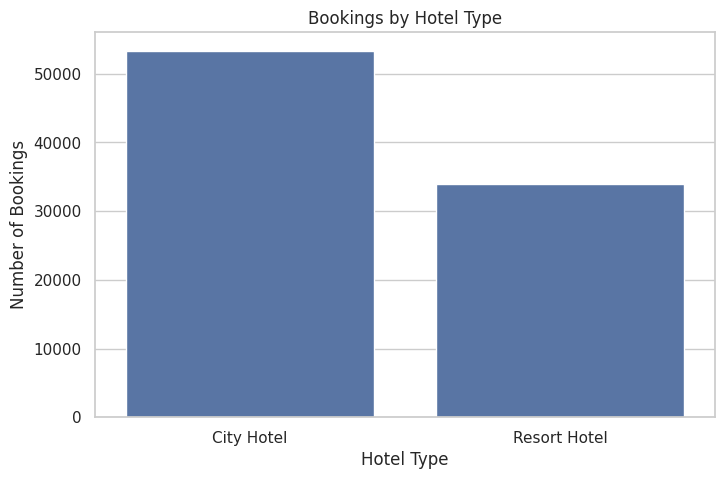

In [ ]:
hotel_bookings = cleaned_df["hotel"].value_counts()

display(hotel_bookings.to_frame("Bookings"))

plt.figure(figsize=(8,5))
sns.barplot(x=hotel_bookings.index, y=hotel_bookings.values)
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()


## Basic 3 — How many bookings were canceled?

In [ ]:
canceled_bookings = cleaned_df["is_canceled"].sum()
total_bookings = len(cleaned_df)
cancellation_rate = cleaned_df["is_canceled"].mean() * 100

print("Canceled bookings:", int(canceled_bookings))
print(f"Overall cancellation rate: {cancellation_rate:.2f}%")


Canceled bookings: 23942
Overall cancellation rate: 27.42%


## Basic 4 — What is the most common arrival month for bookings?

Most common arrival month: August
Bookings in that month: 11251


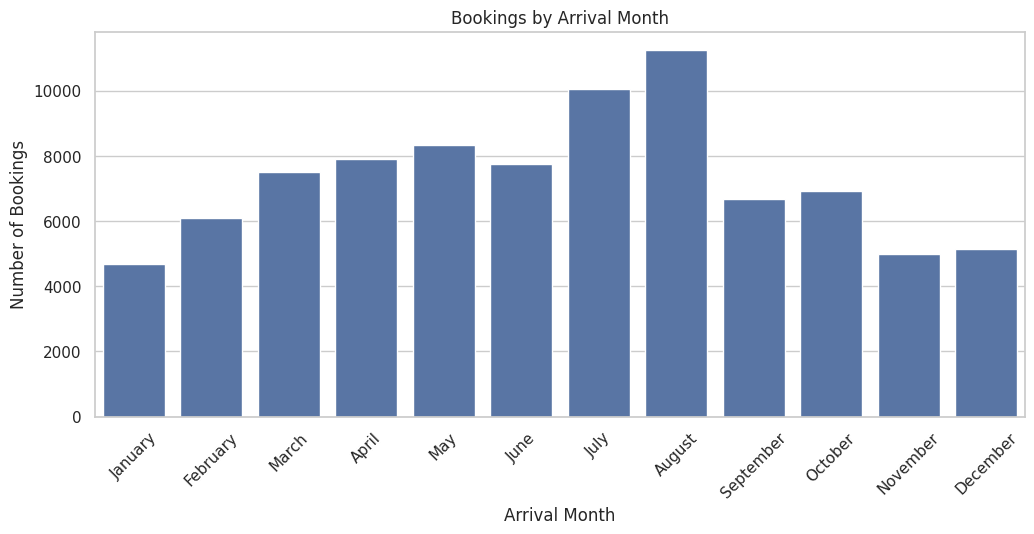

In [ ]:
month_counts = cleaned_df["arrival_date_month"].value_counts()

print("Most common arrival month:", month_counts.idxmax())
print("Bookings in that month:", int(month_counts.max()))

# Calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_bookings = (
    cleaned_df.groupby("arrival_month_num")
    .size()
    .reindex(range(1,13), fill_value=0)
)

plt.figure(figsize=(12,5))
sns.barplot(x=month_order, y=monthly_bookings.values)
plt.title("Bookings by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()


## Basic 5 — What is the average number of special requests per booking?

In [ ]:
avg_special_requests = cleaned_df["total_of_special_requests"].mean()

print(f"Average special requests per booking: {avg_special_requests:.2f}")


Average special requests per booking: 0.70


## Basic 6 — Which country has the highest number of bookings?

In [ ]:
country_counts = cleaned_df["country"].value_counts(dropna=False)

top_country = country_counts.idxmax()
top_country_count = country_counts.max()

print("Country with highest number of bookings:", top_country)
print("Number of bookings:", int(top_country_count))

display(country_counts.head(10).to_frame("Bookings"))


Country with highest number of bookings: PRT
Number of bookings: 27405


,Bookings
country,
PRT,27405
GBR,10425
FRA,8837
ESP,7249
DEU,5386
ITA,3060
IRL,3011
BEL,2081
BRA,1995


## Basic 7 — What is the average daily rate (ADR) for each hotel type?

,Average ADR
hotel,
City Hotel,110.996807
Resort Hotel,99.032970


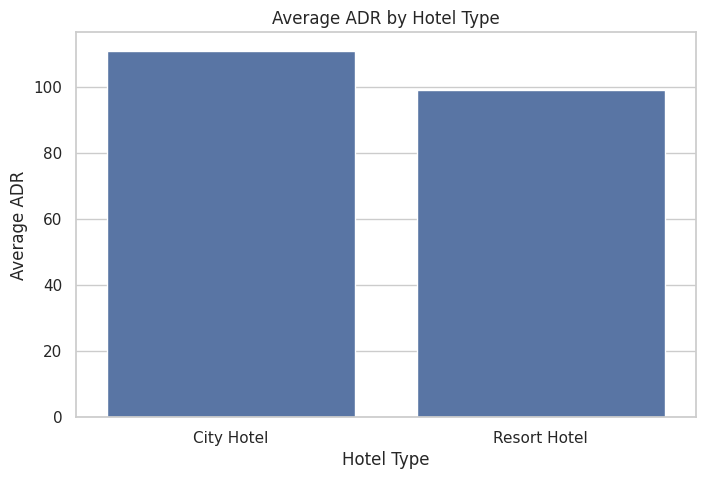

In [ ]:
avg_adr_hotel = (
    cleaned_df.groupby("hotel")["adr"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_adr_hotel.to_frame("Average ADR"))

plt.figure(figsize=(8,5))
sns.barplot(x=avg_adr_hotel.index, y=avg_adr_hotel.values)
plt.title("Average ADR by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")
plt.show()


## Basic 8 — What percentage of guests required car parking spaces?

In [ ]:
parking_percentage = (
    (cleaned_df["required_car_parking_spaces"] > 0).mean() * 100
)

print(f"Percentage of bookings requiring parking: {parking_percentage:.2f}%")


Percentage of bookings requiring parking: 8.38%


## Basic 9 — What is the average stay duration in week nights and weekend nights?

In [ ]:
avg_week_nights = cleaned_df["stays_in_week_nights"].mean()
avg_weekend_nights = cleaned_df["stays_in_weekend_nights"].mean()
avg_total_nights = cleaned_df["total_stay_nights"].mean()

print(f"Average week nights: {avg_week_nights:.2f}")
print(f"Average weekend nights: {avg_weekend_nights:.2f}")
print(f"Average total stay duration: {avg_total_nights:.2f} nights")


Average week nights: 2.63
Average weekend nights: 1.01
Average total stay duration: 3.63 nights


## Basic 10 — How many bookings were made through travel agents?

In [ ]:
agent_bookings = (
    cleaned_df["agent"].ne("Unknown").sum()
)

agent_percentage = agent_bookings / len(cleaned_df) * 100

print("Bookings with a travel agent recorded:", int(agent_bookings))
print(f"Percentage of bookings with a travel agent recorded: {agent_percentage:.2f}%")


Bookings with a travel agent recorded: 75127
Percentage of bookings with a travel agent recorded: 86.04%


# MEDIUM LEVEL EDA

The next 10 are the Medium Level questions from the case study.

## Medium 1 — What is the cancellation rate for each hotel type?

,Cancellation Rate (%)
hotel,
City Hotel,29.965150
Resort Hotel,23.420052


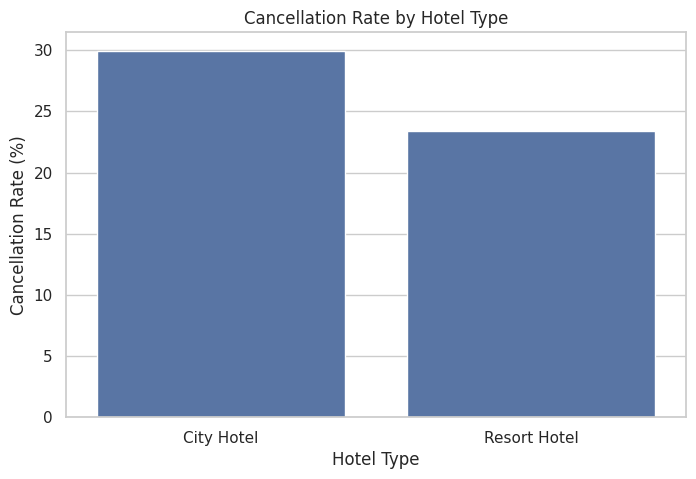

In [ ]:
cancel_rate_hotel = (
    cleaned_df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(cancel_rate_hotel.to_frame("Cancellation Rate (%)"))

plt.figure(figsize=(8,5))
sns.barplot(x=cancel_rate_hotel.index, y=cancel_rate_hotel.values)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()


## Medium 2 — What is the average ADR per market segment?

,Average ADR
market_segment,
Online TA,118.177270
Direct,116.588405
Aviation,100.170396
Offline TA/TO,81.739618
Groups,74.879502
Corporate,68.152743
Undefined,15.000000
Complementary,3.049245


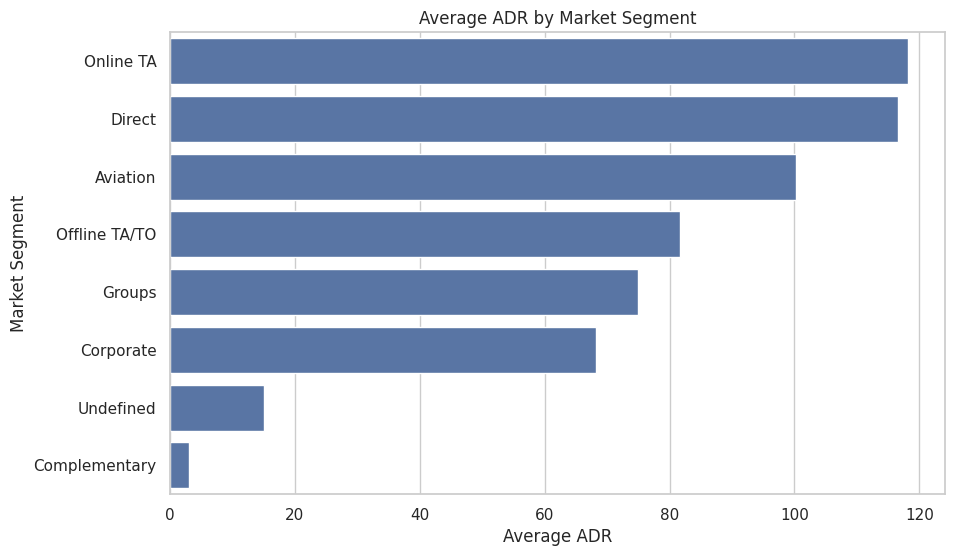

In [ ]:
avg_adr_segment = (
    cleaned_df.groupby("market_segment")["adr"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_adr_segment.to_frame("Average ADR"))

plt.figure(figsize=(10,6))
sns.barplot(x=avg_adr_segment.values, y=avg_adr_segment.index)
plt.title("Average ADR by Market Segment")
plt.xlabel("Average ADR")
plt.ylabel("Market Segment")
plt.show()


## Medium 3 — What is the relationship between lead time and cancellation rate?

,Cancellation Rate (%)
lead_time_band,
0–7,8.419845
8–30,25.339782
31–60,31.544630
61–90,32.458387
91–180,34.901207
181–365,39.565256
366+,40.674956


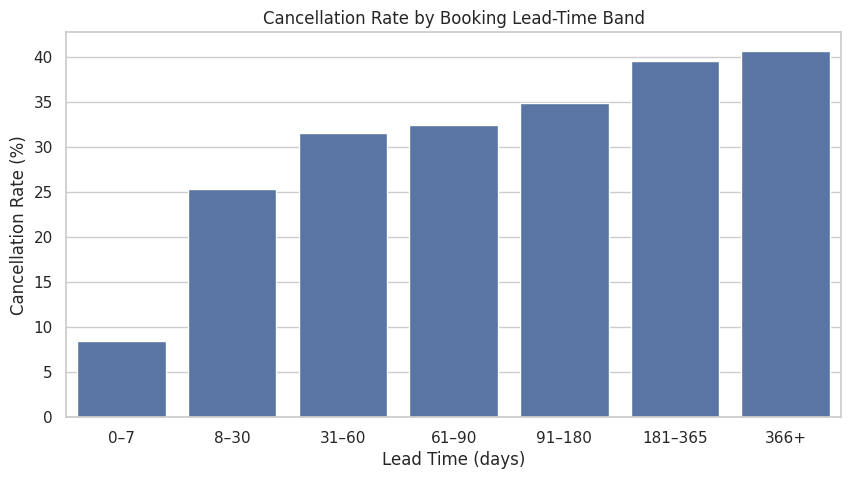

Correlation between lead time and cancellation flag: 0.184


In [ ]:
lead_bins = [-1, 7, 30, 60, 90, 180, 365, np.inf]
lead_labels = ["0–7", "8–30", "31–60", "61–90", "91–180", "181–365", "366+"]

temp = cleaned_df.copy()
temp["lead_time_band"] = pd.cut(
    temp["lead_time"],
    bins=lead_bins,
    labels=lead_labels
)

lead_cancel = (
    temp.groupby("lead_time_band", observed=False)["is_canceled"]
    .mean()
    .mul(100)
)

display(lead_cancel.to_frame("Cancellation Rate (%)"))

plt.figure(figsize=(10,5))
sns.barplot(x=lead_cancel.index.astype(str), y=lead_cancel.values)
plt.title("Cancellation Rate by Booking Lead-Time Band")
plt.xlabel("Lead Time (days)")
plt.ylabel("Cancellation Rate (%)")
plt.show()

print(f"Correlation between lead time and cancellation flag: {cleaned_df['lead_time'].corr(cleaned_df['is_canceled']):.3f}")


## Medium 4 — Which distribution channel has the highest number of bookings?

Top distribution channel: TA/TO
Bookings: 69066


,Bookings
distribution_channel,
TA/TO,69066
Direct,12982
Corporate,5079
GDS,181
Undefined,5


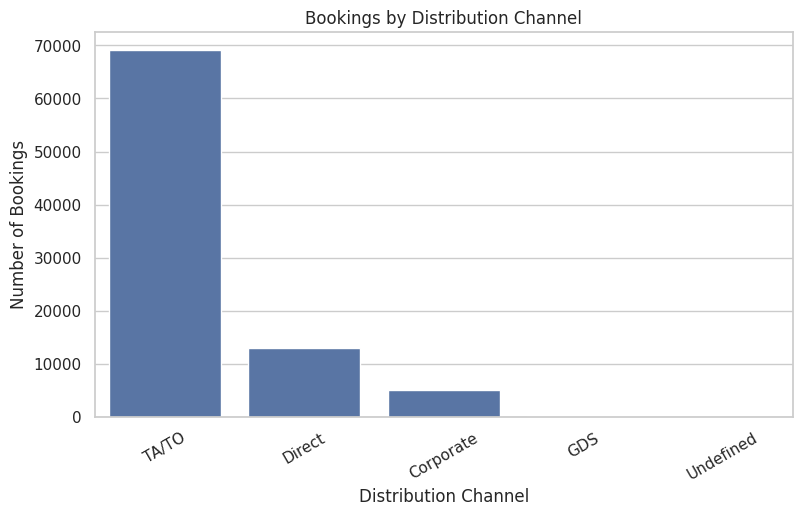

In [ ]:
channel_counts = cleaned_df["distribution_channel"].value_counts()

print("Top distribution channel:", channel_counts.idxmax())
print("Bookings:", int(channel_counts.max()))

display(channel_counts.to_frame("Bookings"))

plt.figure(figsize=(9,5))
sns.barplot(x=channel_counts.index, y=channel_counts.values)
plt.title("Bookings by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30)
plt.show()


## Medium 5 — What is the average number of previous cancellations by hotel type?

In [ ]:
previous_cancel_hotel = (
    cleaned_df.groupby("hotel")["previous_cancellations"]
    .mean()
    .sort_values(ascending=False)
)

display(previous_cancel_hotel.to_frame("Average Previous Cancellations"))


,Average Previous Cancellations
hotel,
City Hotel,0.035749
Resort Hotel,0.021979


## Medium 6 — What is the trend of ADR over the years?

,Average ADR
arrival_date_year,
2015,92.175030
2016,101.544359
2017,118.717215


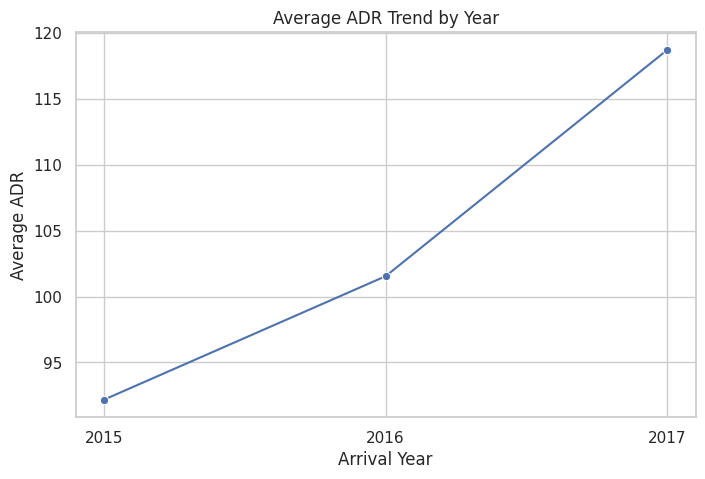

In [ ]:
adr_year = (
    cleaned_df.groupby("arrival_date_year")["adr"]
    .mean()
    .sort_index()
)

display(adr_year.to_frame("Average ADR"))

plt.figure(figsize=(8,5))
sns.lineplot(x=adr_year.index, y=adr_year.values, marker="o")
plt.title("Average ADR Trend by Year")
plt.xlabel("Arrival Year")
plt.ylabel("Average ADR")
plt.xticks(adr_year.index)
plt.show()


## Medium 7 — Which month has the highest revenue?

Month with highest summed ADR: August
Summed ADR: 1697743.33


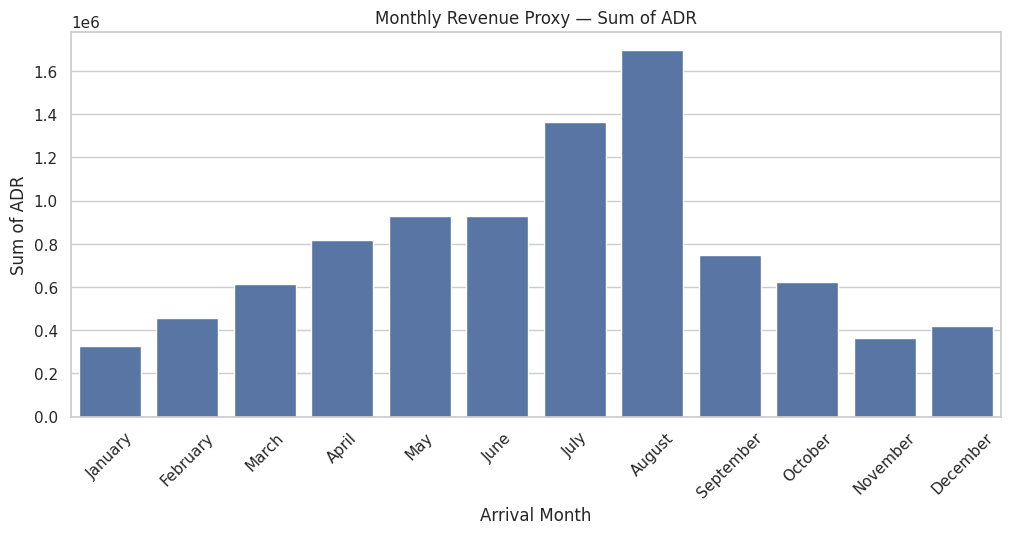

In [ ]:
# The case-study solution idea suggests summing ADR by month.
# This is a proxy rather than accounting revenue because ADR is a daily rate.
monthly_adr_sum = (
    cleaned_df.groupby(["arrival_month_num", "arrival_date_month"])["adr"]
    .sum()
    .sort_values(ascending=False)
)

top_month = monthly_adr_sum.index[0]
print("Month with highest summed ADR:", top_month[1])
print("Summed ADR:", round(monthly_adr_sum.iloc[0], 2))

month_revenue_proxy = (
    cleaned_df.groupby("arrival_month_num")["adr"]
    .sum()
    .reindex(range(1,13), fill_value=0)
)

plt.figure(figsize=(12,5))
sns.barplot(x=month_order, y=month_revenue_proxy.values)
plt.title("Monthly Revenue Proxy — Sum of ADR")
plt.xlabel("Arrival Month")
plt.ylabel("Sum of ADR")
plt.xticks(rotation=45)
plt.show()


## Medium 8 — What is the impact of special requests on ADR?

,Average ADR
total_of_special_requests,
0,99.666678
1,109.656192
2,118.590819
3,125.070790
4,131.088687
5,129.980000


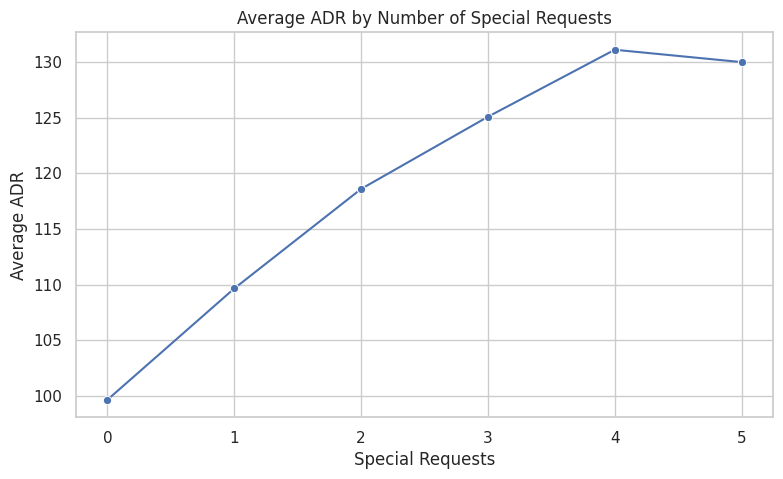

Correlation between special requests and ADR: 0.138


In [ ]:
special_adr = (
    cleaned_df.groupby("total_of_special_requests")["adr"]
    .mean()
)

display(special_adr.to_frame("Average ADR"))

plt.figure(figsize=(9,5))
sns.lineplot(x=special_adr.index, y=special_adr.values, marker="o")
plt.title("Average ADR by Number of Special Requests")
plt.xlabel("Special Requests")
plt.ylabel("Average ADR")
plt.show()

print(f"Correlation between special requests and ADR: {cleaned_df['total_of_special_requests'].corr(cleaned_df['adr']):.3f}")


## Medium 9 — What is the average stay duration for repeated guests versus new guests?

,Average Stay Duration
repeated_guest_label,
New Guest,3.700243
Repeated Guest,1.927086


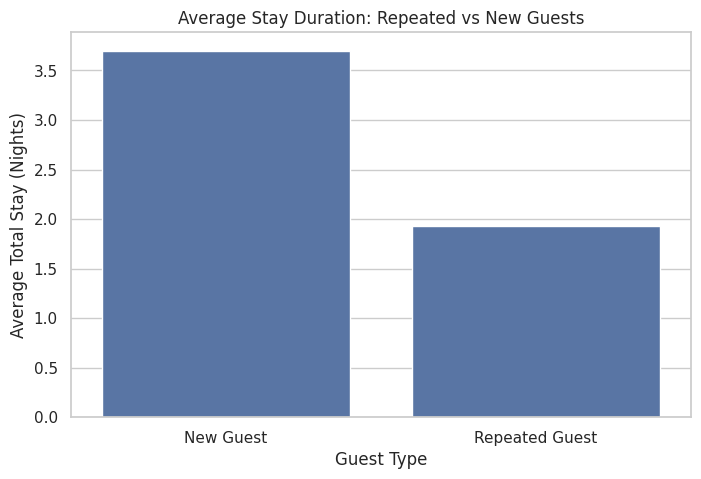

In [ ]:
stay_by_guest = (
    cleaned_df.groupby("repeated_guest_label")["total_stay_nights"]
    .mean()
    .sort_values(ascending=False)
)

display(stay_by_guest.to_frame("Average Stay Duration"))

plt.figure(figsize=(8,5))
sns.barplot(x=stay_by_guest.index, y=stay_by_guest.values)
plt.title("Average Stay Duration: Repeated vs New Guests")
plt.xlabel("Guest Type")
plt.ylabel("Average Total Stay (Nights)")
plt.show()


## Medium 10 — Which room type has the highest number of bookings?

Most-booked reserved room type: A
Bookings: 56485


,Bookings
reserved_room_type,
A,56485
D,17385
E,6047
F,2823
G,2051
B,999
C,915
H,596
L,6


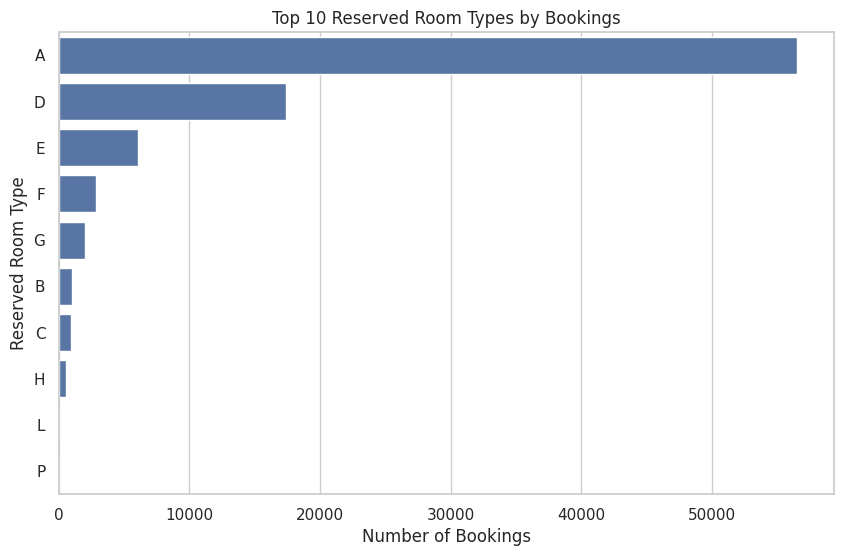

In [ ]:
room_counts = cleaned_df["reserved_room_type"].value_counts()

print("Most-booked reserved room type:", room_counts.idxmax())
print("Bookings:", int(room_counts.max()))

display(room_counts.to_frame("Bookings").head(15))

plt.figure(figsize=(10,6))
sns.barplot(x=room_counts.head(10).values, y=room_counts.head(10).index)
plt.title("Top 10 Reserved Room Types by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Reserved Room Type")
plt.show()


# ADVANCED ANALYSIS

The document specifies five advanced questions. These sections implement the requested techniques where appropriate.

## Advanced 1 — What factors significantly impact the cancellation rate? — Logistic Regression

ROC-AUC: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.96      0.84     12674
           1       0.62      0.16      0.25      4789

    accuracy                           0.74     17463
   macro avg       0.69      0.56      0.55     17463
weighted avg       0.71      0.74      0.68     17463



,Feature,Coefficient,Odds Ratio
3,previous_cancellations,0.607326,1.835517
0,lead_time,0.362072,1.436302
8,adults,0.212019,1.236171
9,children,0.183615,1.201553
10,babies,0.010393,1.010448
5,days_in_waiting_list,-0.047178,0.953918
7,is_repeated_guest,-0.215519,0.806123
1,booking_changes,-0.322445,0.724375
2,total_of_special_requests,-0.344359,0.708675
4,previous_bookings_not_canceled,-0.560122,0.571140


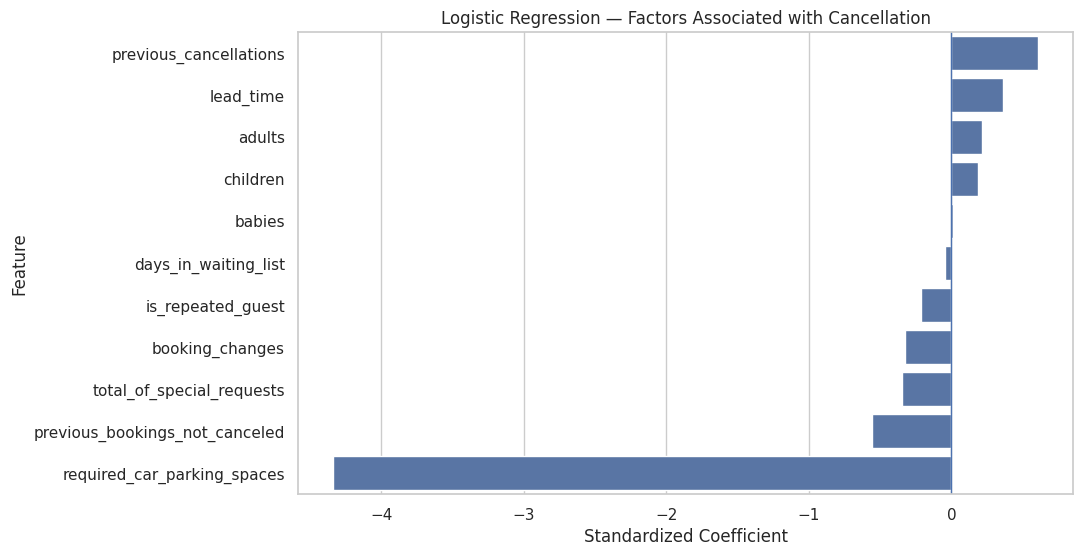

In [ ]:
# Select interpretable numeric predictors specified/implied by the case study.
features = [
    "lead_time",
    "booking_changes",
    "total_of_special_requests",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "is_repeated_guest",
    "adults",
    "children",
    "babies"
]

model_df = cleaned_df[features + ["is_canceled"]].copy()

# Remove invalid rows for model inputs
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

X = model_df[features]
y = model_df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)
prob = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, prob), 3))
print("\nClassification Report:")
print(classification_report(y_test, pred))

coef = log_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef,
    "Odds Ratio": np.exp(coef)
}).sort_values("Coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")
plt.axvline(0, linewidth=1)
plt.title("Logistic Regression — Factors Associated with Cancellation")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.show()


## Advanced 2 — How does ADR vary with adults, children, and babies? — Multiple Regression

R²: 0.194
MAE: 35.559


,Feature,Coefficient
0,adults,19.656829
1,children,38.873811
2,babies,5.992449


Intercept: 63.87


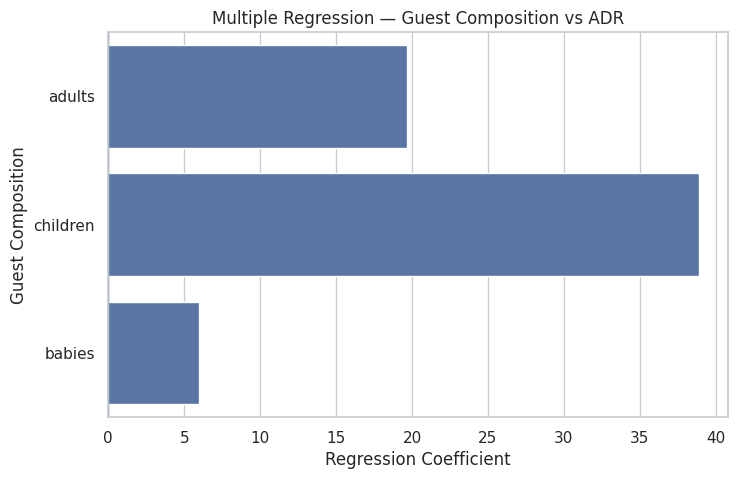

In [ ]:
adr_features = ["adults", "children", "babies"]

adr_model_df = cleaned_df[adr_features + ["adr"]].replace(
    [np.inf, -np.inf], np.nan
).dropna()

X_adr = adr_model_df[adr_features]
y_adr = adr_model_df["adr"]

X_train, X_test, y_train, y_test = train_test_split(
    X_adr, y_adr, test_size=0.20, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

pred_adr = linear_model.predict(X_test)

print("R²:", round(r2_score(y_test, pred_adr), 3))
print("MAE:", round(mean_absolute_error(y_test, pred_adr), 3))

adr_coef = pd.DataFrame({
    "Feature": adr_features,
    "Coefficient": linear_model.coef_
})

display(adr_coef)
print("Intercept:", round(linear_model.intercept_, 3))

plt.figure(figsize=(8,5))
sns.barplot(data=adr_coef, x="Coefficient", y="Feature")
plt.axvline(0, linewidth=1)
plt.title("Multiple Regression — Guest Composition vs ADR")
plt.xlabel("Regression Coefficient")
plt.ylabel("Guest Composition")
plt.show()


## Advanced 3 — What is the impact of booking changes on guest satisfaction as indicated by special requests?

Correlation between booking changes and special requests: 0.016


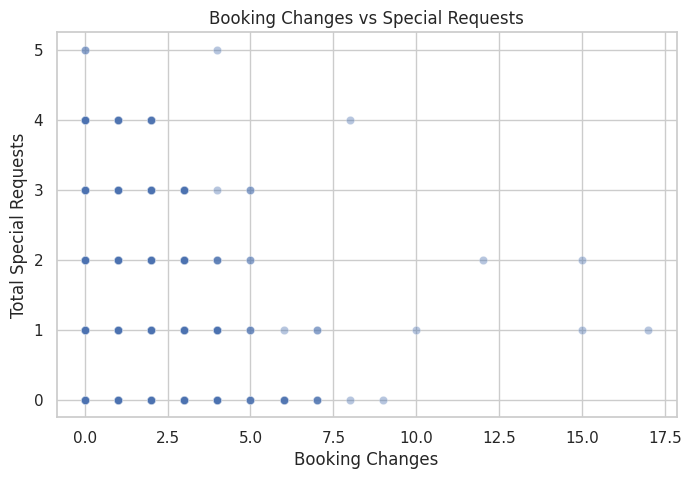

,Average Special Requests
booking_changes,
0,0.697058
1,0.682110
2,0.737172
3,0.826286
4,0.820225
5,0.836207
6,0.864407
7,0.645161
8,0.882353


In [ ]:
corr_value = cleaned_df["booking_changes"].corr(
    cleaned_df["total_of_special_requests"]
)

print(f"Correlation between booking changes and special requests: {corr_value:.3f}")

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=cleaned_df.sample(min(10000, len(cleaned_df)), random_state=42),
    x="booking_changes",
    y="total_of_special_requests",
    alpha=0.4
)
plt.title("Booking Changes vs Special Requests")
plt.xlabel("Booking Changes")
plt.ylabel("Total Special Requests")
plt.show()

impact_table = (
    cleaned_df.groupby("booking_changes")["total_of_special_requests"]
    .mean()
    .head(15)
)

display(impact_table.to_frame("Average Special Requests"))


## Advanced 4 — What is the seasonal impact on booking cancellations?

,arrival_date_month,Cancellation Rate (%)
0,January,22.084843
1,February,23.166530
2,March,24.327563
3,April,30.365962
4,May,29.100719
5,June,30.270619
6,July,31.737659
7,August,32.148253
8,September,24.408506
9,October,23.592261


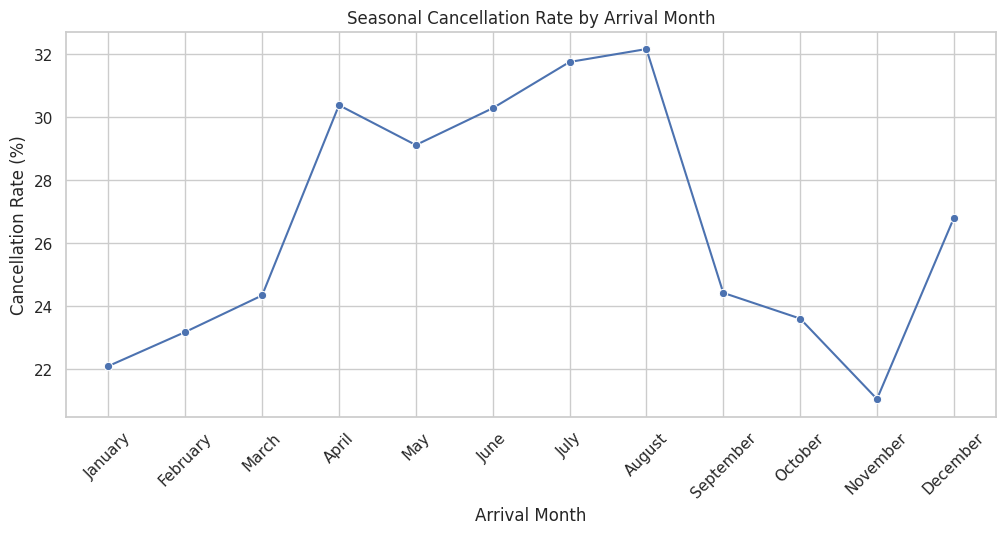

In [ ]:
seasonal_cancel = (
    cleaned_df.groupby(["arrival_month_num", "arrival_date_month"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("arrival_month_num")
)

display(
    seasonal_cancel[["arrival_date_month", "is_canceled"]]
    .rename(columns={"is_canceled": "Cancellation Rate (%)"})
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=seasonal_cancel,
    x="arrival_date_month",
    y="is_canceled",
    marker="o"
)
plt.title("Seasonal Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()


## Advanced 5 — How does booking lead-time distribution vary between different market segments?

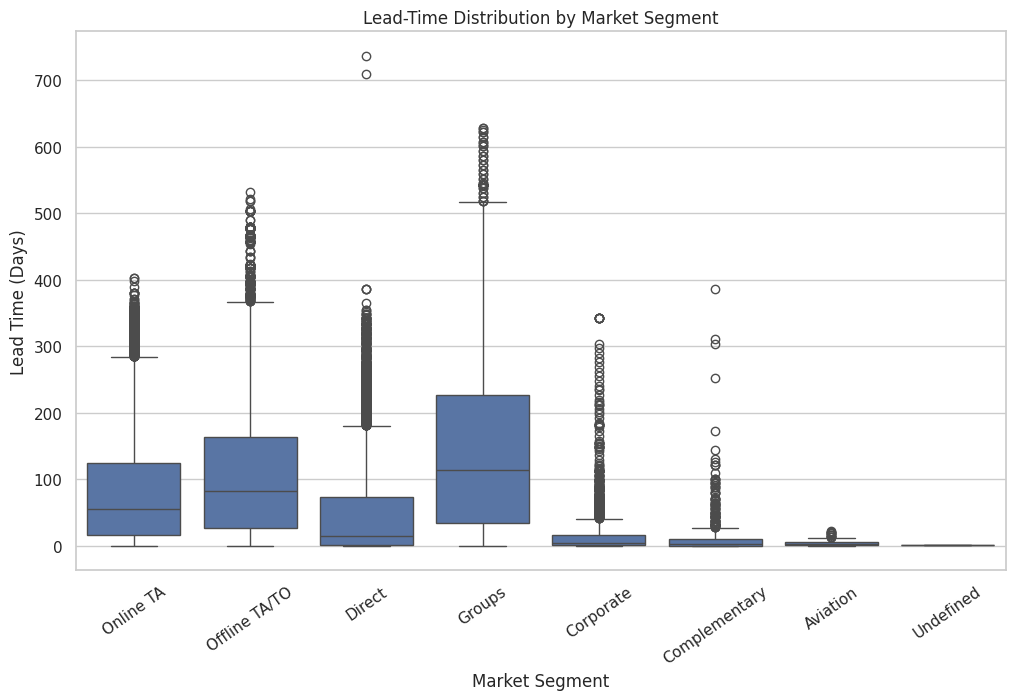

,count,mean,median,min,max
market_segment,,,,,
Groups,4923,147.765590,114.0,0,629
Offline TA/TO,13870,105.946864,82.0,0,532
Online TA,51578,79.862344,55.0,0,403
Direct,11801,48.807474,15.0,0,737
Corporate,4210,16.252257,5.0,0,343
Complementary,702,13.635328,3.0,0,386
Aviation,227,4.281938,3.0,0,23
Undefined,2,1.500000,1.5,1,2


In [ ]:
# Box plot for the main market segments
segment_order = (
    cleaned_df["market_segment"]
    .value_counts()
    .index
)

plt.figure(figsize=(12,7))
sns.boxplot(
    data=cleaned_df,
    x="market_segment",
    y="lead_time",
    order=segment_order
)
plt.title("Lead-Time Distribution by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=35)
plt.show()

lead_segment_summary = (
    cleaned_df.groupby("market_segment")["lead_time"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(lead_segment_summary)


# Additional Business Analysis

These summaries help connect the EDA to the case-study objectives without introducing unrelated analyses.

## Booking Trends

,arrival_date_year,arrival_month_num,arrival_date_month,Bookings
0,2015,7,July,1671
1,2015,8,August,2449
2,2015,9,September,2832
3,2015,10,October,2699
4,2015,11,November,1663
5,2015,12,December,1980
6,2016,1,January,1849
7,2016,2,February,2805
8,2016,3,March,3830
9,2016,4,April,3763


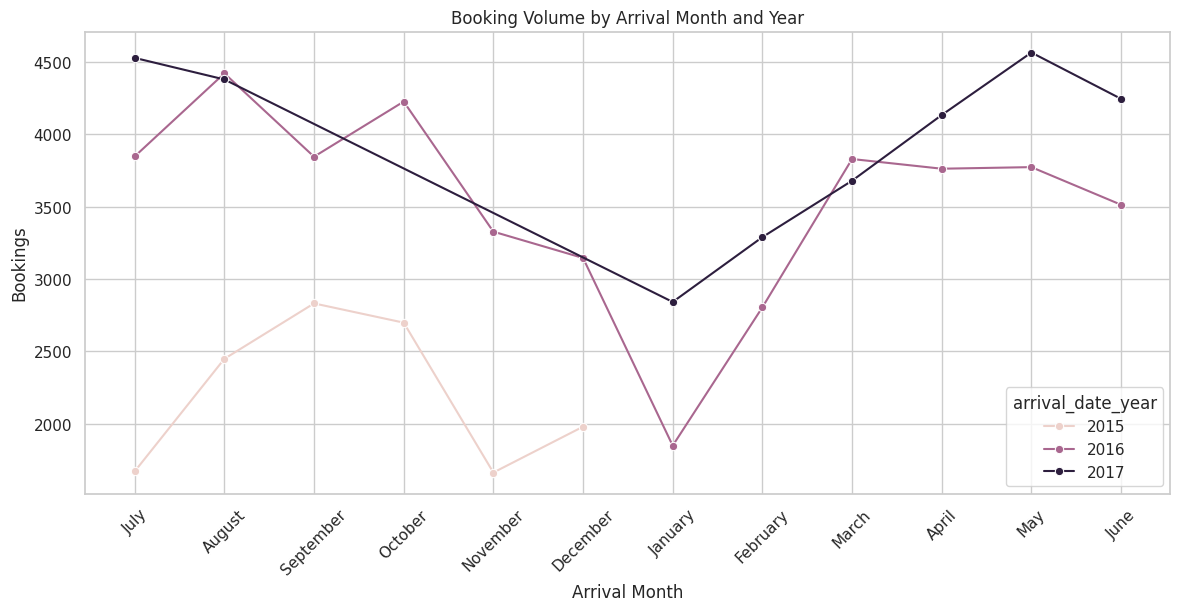

In [ ]:
booking_year_month = (
    cleaned_df.groupby(
        ["arrival_date_year", "arrival_month_num", "arrival_date_month"]
    )
    .size()
    .reset_index(name="Bookings")
    .sort_values(["arrival_date_year", "arrival_month_num"])
)

display(booking_year_month.head(20))

plt.figure(figsize=(14,6))
sns.lineplot(
    data=booking_year_month,
    x="arrival_date_month",
    y="Bookings",
    hue="arrival_date_year",
    marker="o"
)
plt.title("Booking Volume by Arrival Month and Year")
plt.xlabel("Arrival Month")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()


## Cancellation Profile by Lead Time

,lead_time,bookings,cancellation_rate
0,0,5978,5.904985
1,1,3216,6.654229
2,2,1927,9.444733
3,3,1704,9.976526
4,4,1570,9.808917
5,5,1418,11.071932
6,6,1299,12.317167
7,7,1190,12.689076
8,8,1019,18.056919
9,9,900,20.000000


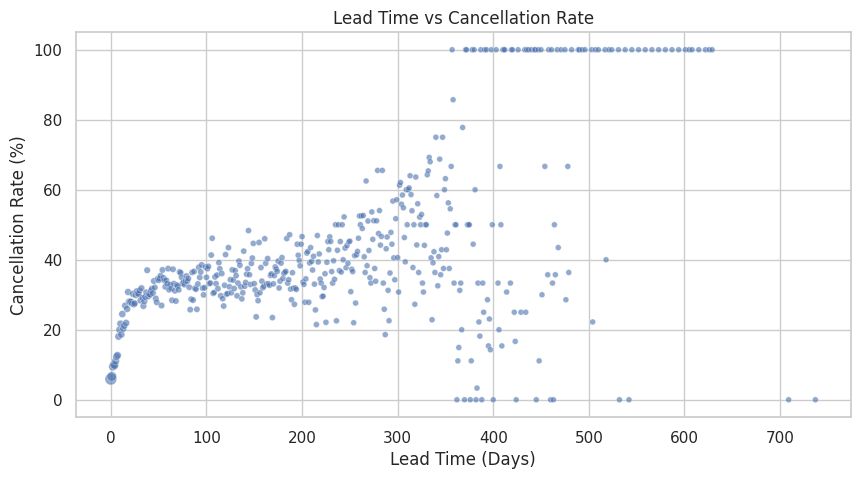

In [ ]:
cancel_profile = (
    cleaned_df.groupby("lead_time")
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancel_profile["cancellation_rate"] *= 100

display(cancel_profile.head(20))

plt.figure(figsize=(10,5))
sns.scatterplot(
    data=cancel_profile,
    x="lead_time",
    y="cancellation_rate",
    size="bookings",
    alpha=0.6,
    legend=False
)
plt.title("Lead Time vs Cancellation Rate")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.show()


## Guest Preferences — Meal, Customer Type, and Special Requests

In [ ]:
fig_data = {
    "Meal": cleaned_df["meal"].value_counts().head(10),
    "Customer Type": cleaned_df["customer_type"].value_counts(),
    "Special Requests": cleaned_df["total_of_special_requests"].value_counts().sort_index()
}

for title, series in fig_data.items():
    print("\n", title)
    display(series.to_frame("Bookings"))



 Meal


,Bookings
meal,
BB,67921
SC,9475
HB,9069
Undefined,490
FB,358



 Customer Type


,Bookings
customer_type,
Transient,71946
Transient-Party,11684
Contract,3139
Group,544



 Special Requests


,Bookings
total_of_special_requests,
0,43825
1,29010
2,11805
3,2317
4,320
5,36


## Revenue Management Summary — ADR by Hotel, Segment, and Month

In [ ]:
adr_summary = {
    "By Hotel": cleaned_df.groupby("hotel")["adr"].mean().sort_values(ascending=False),
    "By Market Segment": cleaned_df.groupby("market_segment")["adr"].mean().sort_values(ascending=False),
    "By Arrival Month": cleaned_df.groupby(["arrival_month_num","arrival_date_month"])["adr"].mean().sort_values(ascending=False)
}

for title, series in adr_summary.items():
    print("\n" + title)
    display(series.to_frame("Average ADR"))



By Hotel


,Average ADR
hotel,
City Hotel,110.996807
Resort Hotel,99.032970



By Market Segment


,Average ADR
market_segment,
Online TA,118.177270
Direct,116.588405
Aviation,100.170396
Offline TA/TO,81.739618
Groups,74.879502
Corporate,68.152743
Undefined,15.000000
Complementary,3.049245



By Arrival Month


,,Average ADR
arrival_month_num,arrival_date_month,
8,August,150.897105
7,July,135.551901
6,June,119.761425
9,September,112.107640
5,May,111.215323
4,April,103.629036
10,October,90.146861
3,March,81.599188
12,December,81.457015


# Final Results Summary

Run this section after all analysis cells. It automatically collects the major numeric findings.

In [ ]:
# Core findings
top_hotel = cleaned_df["hotel"].value_counts().idxmax()
top_hotel_bookings = cleaned_df["hotel"].value_counts().max()

top_month = cleaned_df["arrival_date_month"].value_counts().idxmax()
top_month_bookings = cleaned_df["arrival_date_month"].value_counts().max()

top_country = cleaned_df["country"].value_counts().idxmax()
top_country_bookings = cleaned_df["country"].value_counts().max()

top_channel = cleaned_df["distribution_channel"].value_counts().idxmax()
top_channel_bookings = cleaned_df["distribution_channel"].value_counts().max()

top_room = cleaned_df["reserved_room_type"].value_counts().idxmax()
top_room_bookings = cleaned_df["reserved_room_type"].value_counts().max()

highest_adr_hotel = avg_adr_hotel.idxmax()
highest_adr_value = avg_adr_hotel.max()

highest_cancel_hotel = cancel_rate_hotel.idxmax()
highest_cancel_rate = cancel_rate_hotel.max()

highest_adr_segment = avg_adr_segment.idxmax()
highest_adr_segment_value = avg_adr_segment.max()

print("===== ELITE HOTELS — KEY RESULTS =====")
print(f"Average lead time: {avg_lead_time:.2f} days")
print(f"Total bookings: {len(cleaned_df):,}")
print(f"Canceled bookings: {canceled_bookings:,}")
print(f"Overall cancellation rate: {cancellation_rate:.2f}%")
print(f"Most-booked hotel type: {top_hotel} ({top_hotel_bookings:,} bookings)")
print(f"Most common arrival month: {top_month} ({top_month_bookings:,} bookings)")
print(f"Top booking country: {top_country} ({top_country_bookings:,} bookings)")
print(f"Average special requests: {avg_special_requests:.2f}")
print(f"Highest average ADR hotel: {highest_adr_hotel} ({highest_adr_value:.2f})")
print(f"Parking required: {parking_percentage:.2f}% of bookings")
print(f"Average total stay: {avg_total_nights:.2f} nights")
print(f"Bookings with travel agent recorded: {agent_bookings:,} ({agent_percentage:.2f}%)")
print(f"Highest cancellation-rate hotel: {highest_cancel_hotel} ({highest_cancel_rate:.2f}%)")
print(f"Highest-average-ADR market segment: {highest_adr_segment} ({highest_adr_segment_value:.2f})")
print(f"Top distribution channel: {top_channel} ({top_channel_bookings:,} bookings)")
print(f"Most-booked reserved room type: {top_room} ({top_room_bookings:,} bookings)")


===== ELITE HOTELS — KEY RESULTS =====
Average lead time: 79.84 days
Total bookings: 87,313
Canceled bookings: 23,942
Overall cancellation rate: 27.42%
Most-booked hotel type: City Hotel (53,372 bookings)
Most common arrival month: August (11,251 bookings)
Top booking country: PRT (27,405 bookings)
Average special requests: 0.70
Highest average ADR hotel: City Hotel (111.00)
Parking required: 8.38% of bookings
Average total stay: 3.63 nights
Bookings with travel agent recorded: 75,127 (86.04%)
Highest cancellation-rate hotel: City Hotel (29.97%)
Highest-average-ADR market segment: Online TA (118.18)
Top distribution channel: TA/TO (69,066 bookings)
Most-booked reserved room type: A (56,485 bookings)


# Business Recommendations


### 1. Booking and staffing
Use peak arrival months and hotel-level booking volume to plan staffing, room availability, housekeeping, and other operational resources.

### 2. Cancellation management
Focus cancellation-control policies on hotel types, lead-time ranges, market segments, and other predictors identified by the logistic regression.

### 3. Revenue management
Use ADR differences across hotel types and market segments to support differentiated pricing and promotional strategies.

### 4. Guest preferences
Use stay duration, meal preferences, special requests, room types, and guest composition to tailor services and improve the guest experience.

### 5. Marketing and distribution
Use the strongest market segments, countries, and distribution channels to prioritize marketing and travel-agency relationships.

### 6. Further investigation
The dataset does not directly contain a guest satisfaction score. Therefore, special requests should be treated as a **guest-needs indicator**, not a direct satisfaction measure. Future analysis could combine booking data with actual guest feedback or satisfaction scores.


## Final Conclusion

In [ ]:
print(
    "The analysis provides a structured view of hotel booking demand, cancellations, "
    "guest behavior, and ADR. The findings can support better operational planning, "
    "cancellation management, targeted marketing, guest-service decisions, and revenue management."
)


The analysis provides a structured view of hotel booking demand, cancellations, guest behavior, and ADR. The findings can support better operational planning, cancellation management, targeted marketing, guest-service decisions, and revenue management.


# Downloading of Final Cleaned Dataset


In [ ]:
from google.colab import files
files.download(cleaned_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>